# Rudolph Scores Analysis

This notebook analyzes the Rudolph scoring system data from the 2025 Punkttabelle.

## Import Libraries

In [15]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("Libraries imported successfully!")

Libraries imported successfully!


## Connect to Database

In [16]:
# Database path
DB_PATH = '../../swim_database_2.sqlite3'

# Create connection
conn = sqlite3.connect(DB_PATH)
print(f"Connected to database: {DB_PATH}")

# List all tables
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
tables = [row[0] for row in cursor.fetchall()]
print(f"\nAvailable tables: {tables}")

Connected to database: ../../swim_database_2.sqlite3

Available tables: ['ingest_events', 'discipline_results_ingest', 'production_events', 'failed_events', 'rudolph_scores']


## Load Rudolph Scores Table

In [17]:
# Load the rudolph_scores table
query = "SELECT * FROM rudolph_scores"
df_rudolph = pd.read_sql_query(query, conn)

print(f"Loaded {len(df_rudolph)} rows from rudolph_scores table")
print(f"\nColumns: {list(df_rudolph.columns)}")
print(f"\nDataFrame Info:")
print(df_rudolph.info())

Loaded 7404 rows from rudolph_scores table

Columns: ['Gender', 'Age', 'Event', 'Points', 'Time', 'ingestion_date']

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7404 entries, 0 to 7403
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Gender          7404 non-null   object
 1   Age             7404 non-null   object
 2   Event           7404 non-null   object
 3   Points          7404 non-null   int64 
 4   Time            7404 non-null   object
 5   ingestion_date  7404 non-null   object
dtypes: int64(1), object(5)
memory usage: 347.2+ KB
None


## Data Overview

In [18]:
# Display first few rows
print("First 10 rows of Rudolph Scores:")
df_rudolph.head(10)

First 10 rows of Rudolph Scores:


,Gender,Age,Event,Points,Time,ingestion_date
0,Male,8,50m Freestyle,20,00:33.68,2025-12-19 14:40:17
1,Male,8,100m Freestyle,20,01:17.71,2025-12-19 14:40:17
2,Male,8,200m Freestyle,20,02:51.20,2025-12-19 14:40:17
3,Male,8,400m Freestyle,20,06:18.30,2025-12-19 14:40:17
4,Male,8,800m Freestyle,20,13:05.70,2025-12-19 14:40:17
5,Male,8,1500m Freestyle,20,24:58.65,2025-12-19 14:40:17
6,Male,8,50m Breaststroke,20,00:45.18,2025-12-19 14:40:17
7,Male,8,100m Breaststroke,20,01:41.49,2025-12-19 14:40:17
8,Male,8,200m Breaststroke,20,03:46.01,2025-12-19 14:40:17
9,Male,8,50m Butterfly,20,00:39.41,2025-12-19 14:40:17


In [19]:
# Basic statistics
print("Data Summary:")
print("=" * 60)
print(f"Total records: {len(df_rudolph)}")
print(f"\nGender distribution:")
print(df_rudolph['Gender'].value_counts())
print(f"\nAge groups:")
print(sorted(df_rudolph['Age'].unique()))
print(f"\nEvents ({df_rudolph['Event'].nunique()} unique):")
print(df_rudolph['Event'].value_counts().sort_index())
print(f"\nPoints range: {df_rudolph['Points'].min()} - {df_rudolph['Points'].max()}")

Data Summary:
Total records: 7404

Gender distribution:
Gender
Male       3674
Female     3390
Unknown     340
Name: count, dtype: int64

Age groups:
['10', '11', '12', '13', '14', '15', '16', '17', '18', '8', '9', 'Unknown']

Events (17 unique):
Event
100m Backstroke           480
100m Breaststroke         229
100m Butterfly            480
100m Freestyle            480
1500m Freestyle           480
200m Backstroke           480
200m Breaststroke         226
200m Butterfly            480
200m Freestyle            480
200m Individual Medley    480
400m Freestyle            480
400m Individual Medley    480
50m Backstroke            480
50m Breaststroke          229
50m Butterfly             480
50m Freestyle             480
800m Freestyle            480
Name: count, dtype: int64

Points range: 1 - 20


## Visualize 100m Freestyle by Age and Points

In [20]:
# Import time conversion function from codebase
import sys
sys.path.insert(0, '../..')
from functions import parse_swim_time_to_seconds

# Filter data for 100m Backstroke and Female gender
df_100m_free = df_rudolph[(df_rudolph['Event'] == '100m Backstroke') & 
                           (df_rudolph['Gender'] == 'Female')].copy()

# Convert time strings to seconds
df_100m_free['Time_Seconds'] = df_100m_free['Time'].apply(parse_swim_time_to_seconds)

# Convert Age to numeric (filter out 'Unknown')
df_100m_free = df_100m_free[df_100m_free['Age'] != 'Unknown'].copy()
df_100m_free['Age_Numeric'] = df_100m_free['Age'].astype(int)

# Sort by Age for proper line plotting
df_100m_free = df_100m_free.sort_values('Age_Numeric')

print(f"Filtered {len(df_100m_free)} records for 100m Backstroke (Female)")
print(f"Age range: {df_100m_free['Age_Numeric'].min()} - {df_100m_free['Age_Numeric'].max()}")
print(f"Points range: {df_100m_free['Points'].min()} - {df_100m_free['Points'].max()}")

Filtered 200 records for 100m Backstroke (Female)
Age range: 8 - 18
Points range: 1 - 20


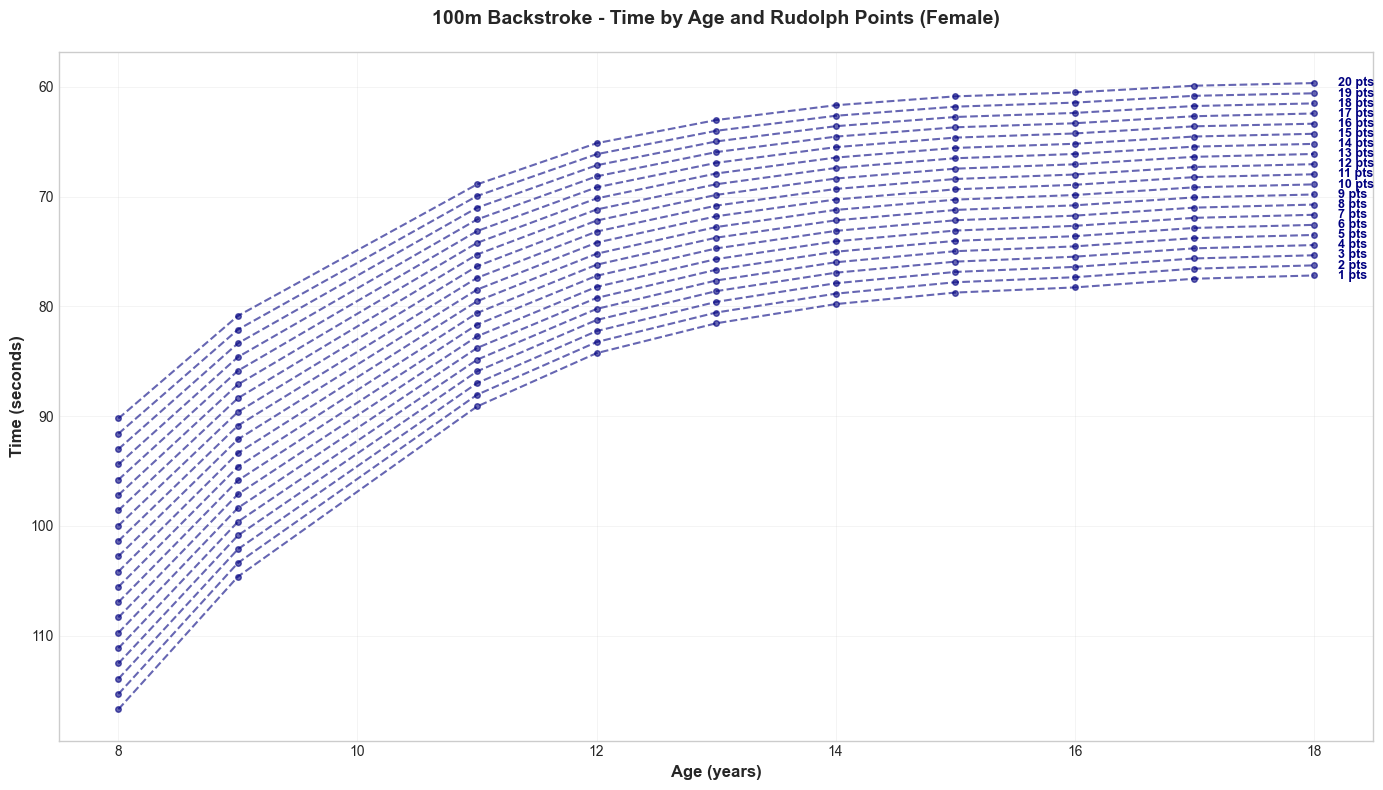

In [22]:
# Create the plot
plt.figure(figsize=(14, 8))

# Set minimal style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Plot each point value as a separate line
for points in sorted(df_100m_free['Points'].unique()):
    df_point = df_100m_free[df_100m_free['Points'] == points]
    plt.plot(df_point['Age_Numeric'], df_point['Time_Seconds'], 
             linestyle='--', linewidth=1.5, color='navy', alpha=0.6, 
             marker='o', markersize=4)
    
    # Add label at the end of each line
    if len(df_point) > 0:
        last_x = df_point['Age_Numeric'].iloc[-1]
        last_y = df_point['Time_Seconds'].iloc[-1]
        plt.text(last_x + 0.2, last_y, f'{points} pts', 
                fontsize=9, va='center', color='navy', fontweight='bold')

# Customize the plot
plt.xlabel('Age (years)', fontsize=12, fontweight='bold')
plt.ylabel('Time (seconds)', fontsize=12, fontweight='bold')
plt.title('100m Backstroke - Time by Age and Rudolph Points (Female)', fontsize=14, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
plt.tight_layout()

# Invert y-axis so faster times (lower seconds) are at the top
plt.gca().invert_yaxis()

plt.show()